# Error analysis

## Imports

In [1]:
import pickle
import shap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


from heart_failure.dataset import split_data
from heart_failure.config.modeling import MIN_RECALL, FE_STEP_NAME, MODEL_STEP_NAME
from heart_failure.config.config import (
    INTERIM_DATA_DIR,
    HEART_DISEASE,
    SEX,
    MODELS_DIR,
    CHEST_PAIN_TYPE,
    ST_SLOPE,
    EXERCISE_ANGINA,
    OLDPEAK,
    AGE
)
from heart_failure.modeling.evaluate import find_best_threshold
from heart_failure.modeling.predict import predict_by_threshold

2026-06-27 11:54:54.982 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

## Model prediction

In [3]:
with open(MODELS_DIR / "xgboost.pkl", "rb") as f:
    model = pickle.load(f)

fe_pipeline = model.named_steps[FE_STEP_NAME]

In [4]:
X_val_transformed = fe_pipeline.transform(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]
best_threshold = find_best_threshold(y_val, y_val_proba, MIN_RECALL)
y_val_pred = predict_by_threshold(model, X_val, best_threshold)

### Confusion Matrix

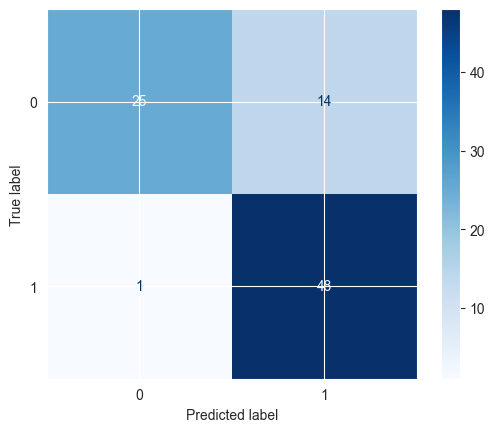

In [5]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap="Blues")
plt.show()

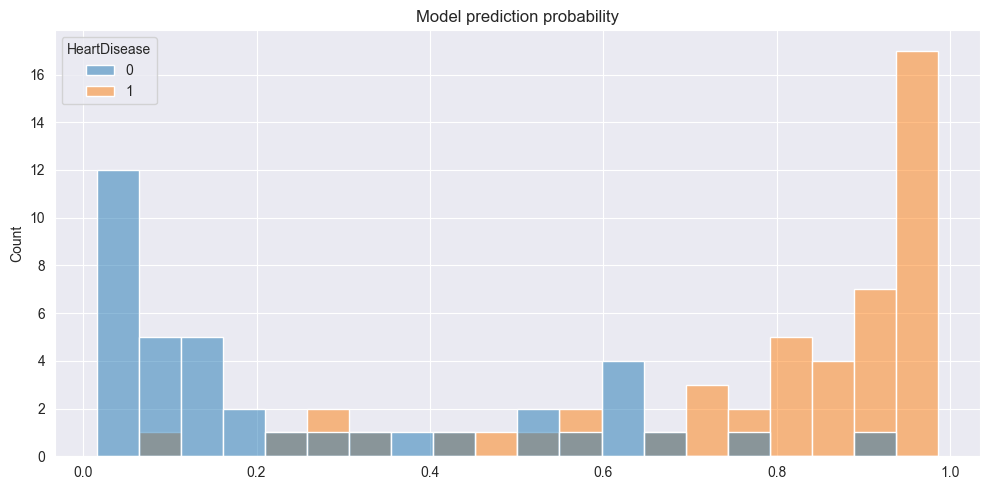

In [6]:
fig, axes = plt.subplots(figsize=(10, 5))

sns.histplot(X_val, x=y_val_proba, hue=y_val, ax=axes, bins=20)
axes.set_title(f"Model prediction probability")

plt.tight_layout()
plt.show()

I want to separately deal with cases that are classified too confidently (incorrectly) and those that are ambiguously classified incorrectly (close to 0.5).

## FP Analysis

In [7]:
negative = y_val == 0
strong_cl = negative & (y_val_proba >= 0.7)
X_val[strong_cl]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
188,50,F,ASY,120.0,328.0,0,Normal,110,Y,1.0,Flat
89,55,M,ASY,140.0,229.0,0,Normal,110,Y,0.5,Flat


In [8]:
X_val_transformed[strong_cl]

,target_encoder__RestingECG,target_encoder__ChestPainType,target_encoder__ST_Slope,binarizer__Age,binarizer__Cholesterol,binarizer__MaxHR,binary_encoder__Sex,binary_encoder__FastingBS,binary_encoder__ExerciseAngina,remainder__RestingBP,remainder__Oldpeak
188,0.521817,0.795385,0.839519,3.0,9.0,1.0,0.0,0.0,1.0,120.0,1.0
89,0.521817,0.795385,0.839519,5.0,3.0,1.0,1.0,0.0,1.0,140.0,0.5


All features seem to point to disease. In both cases St_Slope=Flat, CPT=ASY.

In [9]:
weak_cl = negative & (y_val_proba < 0.7) & (y_val_proba >= 0.5)
X_val[weak_cl]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
843,52,M,TA,118.0,186.0,0,LVH,190,N,0.0,Flat
252,61,M,ASY,125.0,292.0,0,ST,115,Y,0.0,Up
625,53,M,ASY,142.0,226.0,0,LVH,111,Y,0.0,Up
54,52,F,ASY,130.0,180.0,0,Normal,140,Y,1.5,Flat
782,45,F,ASY,138.0,236.0,0,LVH,152,Y,0.2,Flat
685,57,F,ASY,120.0,354.0,0,Normal,163,Y,0.6,Up
586,37,M,NAP,118.0,240.0,0,LVH,165,N,1.0,Flat
802,62,F,ASY,140.0,394.0,0,LVH,157,N,1.2,Flat


There are also many cases with ST_Slope=Flat. Its target encoding is 0.83. Perhaps because of this, the result is almost always classified as class 1.

There are also several cases where Oldpeak=0, St_Slope=Up, but the result is still 1. Is this because of CPT, EA, MaxHR?

It is also clear that in half of the cases the female gender is represented, although in the original distribution there are much fewer of them.

It's worth considering the following:
- When is the class value 0 when ST_Slope=Flat?
- What is the percentage of disease with EA=Y, Oldpeak=0?
- What to do with the misclassification of women?

The red flag so far is the last question.

### SHAP explanation

In [10]:
explainer = shap.TreeExplainer(model.named_steps[MODEL_STEP_NAME])
shap_values = explainer(X_val_transformed[weak_cl])

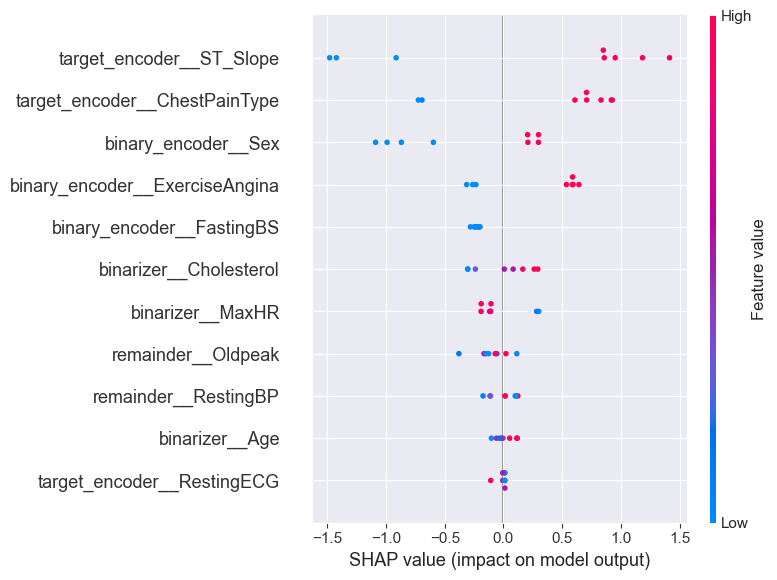

In [11]:
shap.summary_plot(shap_values, X_val_transformed[weak_cl])

We see that for females, the percentage is underestimated in every case. This means the model understands that the percentage is lower for women. So the problem isn't that, but the data itself - there were more "unclear" data among women.

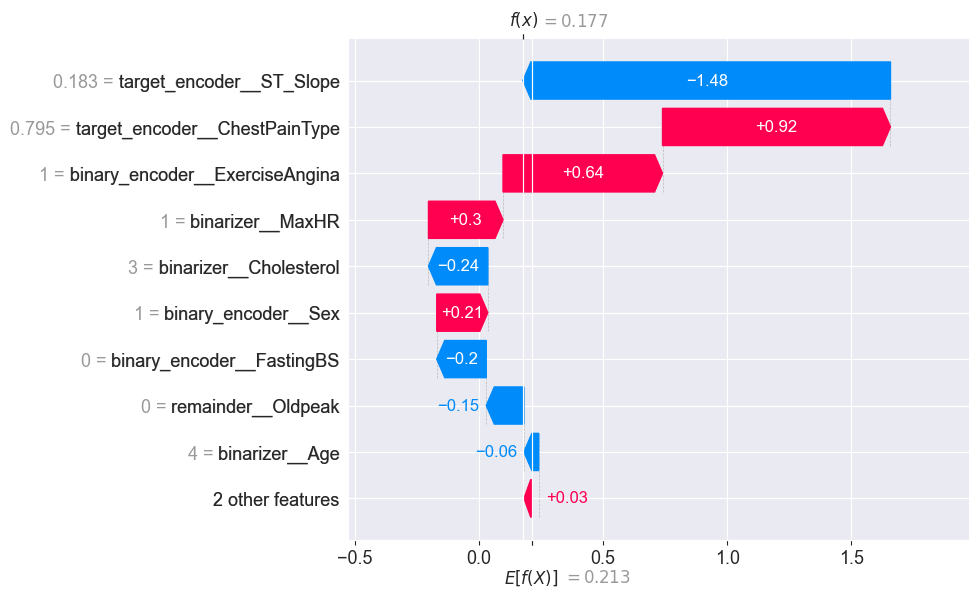

In [12]:
shap.plots.waterfall(shap_values[2])

The relationship between Oldpeak=0 and ST_Slope=Up isn't entirely clear. But perhaps these cases are simply borderline there are both class 1 and class 0. Because we prefer class 1, we get FP.

In [13]:
df_val = X_val.merge(y_val, left_index=True, right_index=True)
df_train = X_train.merge(y_train, left_index=True, right_index=True)
df_val[(y_val_proba >= 0.4) & (y_val_proba <= 0.6)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
813,77,M,ASY,125.0,304.0,0,LVH,162,Y,0.0,Up,1
625,53,M,ASY,142.0,226.0,0,LVH,111,Y,0.0,Up,0
860,65,M,ASY,110.0,248.0,0,LVH,158,N,0.6,Up,1
379,50,M,ASY,120.0,233.0,0,ST,156,Y,0.0,Up,1
310,65,M,ASY,155.0,244.5,0,Normal,154,N,1.0,Up,0
685,57,F,ASY,120.0,354.0,0,Normal,163,Y,0.6,Up,0
586,37,M,NAP,118.0,240.0,0,LVH,165,N,1.0,Flat,0
580,48,M,ASY,140.0,208.0,0,Normal,159,Y,1.5,Up,1
901,58,M,ATA,125.0,220.0,0,Normal,144,N,0.4,Flat,0
41,54,F,NAP,130.0,294.0,0,ST,100,Y,0.0,Flat,1


### EA=Y & Oldpeak=0 & ST_Slope=Up

In [37]:
mask = (X_train[EXERCISE_ANGINA] == "Y") & (X_train[OLDPEAK] == 0) & (X_train[ST_SLOPE] == "Up")
df_train[mask]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
260,46,M,ATA,140.0,275.0,0,Normal,165,Y,0.0,Up,0
367,68,M,ASY,135.0,244.5,0,ST,120,Y,0.0,Up,1
807,35,M,ASY,126.0,282.0,0,LVH,156,Y,0.0,Up,1
372,63,M,ASY,185.0,244.5,0,Normal,98,Y,0.0,Up,1
704,59,M,ATA,140.0,221.0,0,Normal,164,Y,0.0,Up,0
847,52,M,ASY,128.0,255.0,0,Normal,161,Y,0.0,Up,1
763,41,F,NAP,112.0,268.0,0,LVH,172,Y,0.0,Up,0
112,47,M,ASY,140.0,276.0,1,Normal,125,Y,0.0,Up,0
506,40,M,NAP,106.0,240.0,0,Normal,80,Y,0.0,Up,0
543,61,F,ATA,140.0,298.0,1,Normal,120,Y,0.0,Up,0


In general, class 0 appears more often here, but with CPT=ASY, class 1 appears more often.

## FN Analysis

In [35]:
positive = y_val == 1
strong_cl = positive & (y_val_proba <= 0.3)
X_val[strong_cl]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
815,58,M,ASY,125.0,300.0,0,LVH,171,N,0.0,Up
796,41,M,ASY,110.0,172.0,0,LVH,158,N,0.0,Up
915,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat
888,59,M,TA,134.0,204.0,0,Normal,162,N,0.8,Up


The first two cases are similar to the previous FPs, except that MaxHR is high and EA=N. As I understand it, given the differences between Oldpeak=0, CPT=ASY, and ST=Up, these are the decisive factors.

The third case is not surprising. A little later, we'll see that for F x CPT=ATA, the class percentage is very small, so there's no point in adjusting it.

## Female misclassification

- I tried to select the threshold by gender, but it didn't help, and the errors remained.
- Using sample_weights also didn't help

I'm interested in ChestPainType and ST_Slope. Perhaps the problem is the different percentage of the class for women and men.

In [14]:
y_train.groupby([X_train[CHEST_PAIN_TYPE], X_train[SEX]]).mean()

ChestPainType  Sex
ASY            F      0.562500
               M      0.834483
ATA            F      0.046512
               M      0.185185
NAP            F      0.131579
               M      0.459459
TA             F      0.142857
               M      0.481481
Name: HeartDisease, dtype: float64

In [15]:
y_train.groupby([X_train[ST_SLOPE], X_train[SEX]]).mean()

ST_Slope  Sex
Down      F      1.000000
          M      0.783784
Flat      F      0.538462
          M      0.897436
Up        F      0.049383
          M      0.236181
Name: HeartDisease, dtype: float64

The percentages are completely different. But this does not change the fact that with ST_Slope=Down and ChestPainType=ASY they are > 0.5, and the model will still predict towards class 1.

In [22]:
proba_bins = pd.qcut(y_val_proba, q=5)
X_val.groupby([proba_bins, SEX, y_val], observed=False)[AGE].count()

                  Sex  HeartDisease
(0.0148, 0.0998]  F    0                6
                       1                0
                  M    0               11
                       1                1
(0.0998, 0.448]   F    0                2
                       1                1
                  M    0               10
                       1                4
(0.448, 0.756]    F    0                5
                       1                2
                  M    0                4
                       1                7
(0.756, 0.932]    F    0                0
                       1                2
                  M    0                1
                       1               14
(0.932, 0.986]    F    0                0
                       1                0
                  M    0                0
                       1               18
Name: Age, dtype: int64

In fact, the first bin contains a fair number of female samples. This means it's not necessarily a case of poor prediction. There are simply more such ambiguous cases. So the question is: are these ambiguous cases or is it a female-specific feature?

In three cases of weak FP, there were "strong" CPT=ASY and ST_Slope=Flat, Oldpeak>0, meaning such errors also occur for men. When we look at the percentage of class 1 for this feature set, it's also 0.5, so it's not surprising that these cases are erroneous.